# Лабораторная 3
## Методы сопряженных градиентов
### Задачи
1) График целевой функции (квадратичная, ф-я Розенброка, ф-я Химмельблау): в 3D (поверхность) и 2D (линии уровня)
2) Метод, точность eps, количество итераций, количество вычисленных значений функции и её градиента (в сумме), точка минимума
3) Топография целевой функции (линии уровня с точками x_k и стрелками от x_k к x_k+1, если много итераций, то  изображать не все точки (несколько первых и несколько последних со стрелками)).
   График |W_k| в зависимости от k (в обычной и log системе) (т.е. 2 графика)
### Контрольные вопросы
1) Постановка задачи
2) Знать методы
3) Сильные и слабые стороны методов

### Определение функций и констант

In [17]:
import matplotlib.pyplot as plt
from autograd import hessian
import numpy as np
import math


f_quad = lambda x, y: 10 * x**2 + y**2
f_rosen = lambda x, y: (1 - x)**2 + 100*(y - x**2)**2
f_himmel = lambda x, y: (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# градиенты
def grad_quad(x, y):
    return np.array([20*x, 2*y])

def grad_rosen(x, y):
    dx = -2*(1-x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def grad_himmel(x, y):
    dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([dx, dy])

# матрицы Гессе 
# для квадратичной функции
Q = np.array([
    [20, 0],
    [0, 2]
])

# для функции Розенброка
def hess_rosen(x, y):
    H_func = hessian(lambda v: f_rosen(v[0], v[1]))
    return np.array(H_func(np.array([x, y])))
# для функции Химмельблау
def hess_himmel(x, y):
    H_func = hessian(lambda v: f_himmel(v[0], v[1]))
    return np.array(H_func(np.array([x, y])))


# золотое сечение
def bracket_minimum(phi, x, p, step=0.01):
    a = 0
    b = step

    phi_calls = 0

    fa = phi(x, a, p)
    fb = phi(x, b, p)
    phi_calls += 2

    if fa < fb:
        return a, b, phi_calls

    while True:
        step *= 2
        c = b + step
        fc = phi(x, c, p)
        phi_calls += 1

        if fb < fc:
            return a, c, phi_calls

        a = b
        b = c
        fb = fc

def golden_ratio(phi, x, p, eps=1e-6):
    a, b, phi_calls = bracket_minimum(phi, x, p)

    t = (math.sqrt(5) - 1) / 2

    x1 = b - t*(b-a)
    x2 = a + t*(b-a)

    y1 = phi(x, x1, p)
    y2 = phi(x, x2, p)

    phi_calls += 2

    while abs(b-a) > eps:

        if y1 < y2:
            b = x2
            x2 = x1
            y2 = y1
            x1 = b - t*(b-a)
            y1 = phi(x, x1, p)
        else:
            a = x1
            x1 = x2
            y1 = y2
            x2 = a + t*(b-a)
            y2 = phi(x, x2, p)

        phi_calls += 1

    return (a+b)/2, phi_calls

### График целевой функции

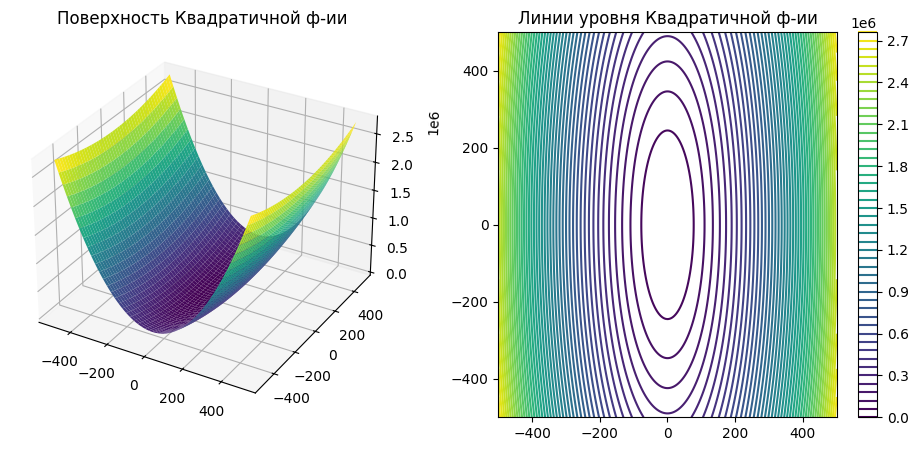

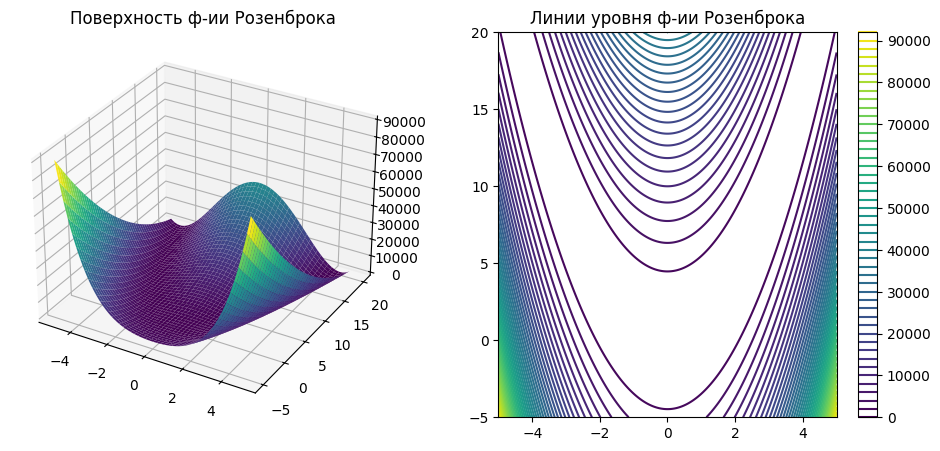

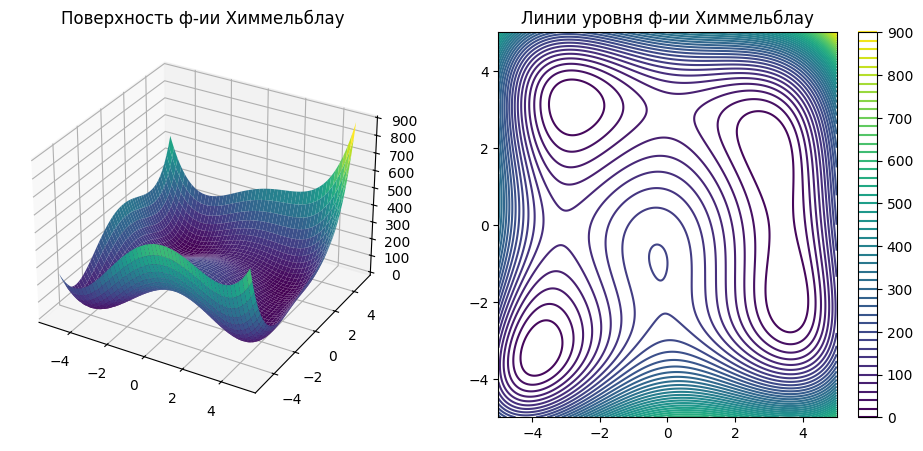

In [ ]:
functions = [
    ("Квадратичной ф-ии", f_quad, (-500, 500), (-500, 500)),
    ("ф-ии Розенброка", f_rosen, (-5, 5), (-5, 20)),
    ("ф-ии Химмельблау", f_himmel, (-5, 5), (-5, 5))
]

for name, func, x_segment, y_segment in functions:
    x = np.linspace(x_segment[0], x_segment[1], 400)
    y = np.linspace(y_segment[0], y_segment[1], 400)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    fig = plt.figure(figsize=(12,5))

    # 3D поверхность
    ax = fig.add_subplot(121, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title("Поверхность " + name)


    # линии уровня
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, levels=50)
    ax2.set_title("Линии уровня " + name)
    plt.colorbar(contour)

    plt.show()

## Методы сопряженных операторов

In [19]:
def conjugate_gradient_method(func, func_grad, gamma_func, x0, alpha_func=None, hess_func=None, eps=1e-4):

    x = np.array(x0, dtype=float)

    phi = lambda x, a, p: func(x[0] + a*p[0], x[1] + a*p[1])

    points = [x.copy()]
    grad_norms = []

    iterations = 0
    calls = 0

    grad = func_grad(x[0], x[1])
    calls += 1

    p = -grad
    grad_norms.append(np.linalg.norm(grad))

    while grad_norms[-1] > eps:
        
        if alpha_func is None:
            alpha, phi_calls = golden_ratio(phi, x, p)
            calls += phi_calls
        else:
            alpha = alpha_func(x, grad, p)

        x_new = x + alpha * p
        points.append(x_new.copy())

        grad_new = func_grad(x_new[0], x_new[1])
        calls += 1

        grad_norms.append(np.linalg.norm(grad_new))
        
        if hess_func is None:
            gamma = gamma_func(grad_new, grad, p)
        else:
            gamma = gamma_func(grad_new, grad, p, hess_func, x_new)

        p = -grad_new + gamma * p

        x = x_new
        grad = grad_new

        iterations += 1

    return x, iterations, calls, np.array(points), np.array(grad_norms)

### Метод Флетчера-Ривса

In [20]:
def gamma_fletcher(g_new, g_old, p):
    norm_old_sq = np.dot(g_old, g_old)
    if norm_old_sq < 1e-10:
        return 0
    return np.dot(g_new, g_new) / norm_old_sq

def alpha_Q(x, grad, p):
    w = -grad
    return (w @ p) / (p @ Q @ p)

functions = [
    ("Квадратичная", f_quad, grad_quad, [1, 5]),
    ("Розенброка", f_rosen, grad_rosen, [-1, 2]),
    ("Химмельблау", f_himmel, grad_himmel, [-2, 0])
]

fletcher_descent_points = []

print("Метод Флетчера-Ривса")

for name, func, grad, start in functions:

    if name == "Квадратичная":
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_fletcher, start, alpha_func=alpha_Q
        )
    else:
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_fletcher, start
        )

    fletcher_descent_points.append([points, grad_norms])

    print()
    print("Функция:", name)
    print("Точка минимума:", minimum)
    print("Количество итераций:", iters)
    print("Количество вычислений:", calls)

Метод Флетчера-Ривса

Функция: Квадратичная
Точка минимума: [-2.77555756e-16  0.00000000e+00]
Количество итераций: 2
Количество вычислений: 3

Функция: Розенброка
Точка минимума: [1.00008131 1.00016309]
Количество итераций: 74
Количество вычислений: 1878

Функция: Химмельблау
Точка минимума: [-2.80511665  3.13131229]
Количество итераций: 146
Количество вычислений: 3666


### Метод Полака-Рибьера

In [21]:
def gamma_polak_ribiere(g_new, g_old, p):
    norm_old_sq = np.dot(g_old, g_old)
    if norm_old_sq < 1e-10:
        return 0
    return np.dot(g_new, (g_new - g_old)) / norm_old_sq

def alpha_Q(x, grad, p):
    w = -grad
    return (w @ p) / (p @ Q @ p)

functions = [
    ("Квадратичная", f_quad, grad_quad, [1, 5]),
    ("Розенброка", f_rosen, grad_rosen, [-1, 2]),
    ("Химмельблау", f_himmel, grad_himmel, [-2, 0])
]

print("Метод Поллака-Рибьера")

polak_descent_points = []

for name, func, grad, start in functions:

    if name == "Квадратичная":
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_polak_ribiere, start, alpha_func=alpha_Q
        )
    else:
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_polak_ribiere, start
        )

    polak_descent_points.append([points, grad_norms])

    print()
    print("Функция:", name)
    print("Точка минимума:", minimum)
    print("Количество итераций:", iters)
    print("Количество вычислений:", calls)


Метод Поллака-Рибьера

Функция: Квадратичная
Точка минимума: [-8.32667268e-17  0.00000000e+00]
Количество итераций: 2
Количество вычислений: 3

Функция: Розенброка
Точка минимума: [1.00000317 1.00000644]
Количество итераций: 21
Количество вычислений: 579

Функция: Химмельблау
Точка минимума: [-2.80511807  3.13131251]
Количество итераций: 7
Количество вычислений: 203


### Метод матрицей Гессе

In [22]:
def gamma_hessian(g_new, g_old, p, hess_func, x):
    H = hess_func(x[0], x[1])
    Hp = H @ p

    denom = np.dot(p, Hp)
    if np.abs(denom) < 1e-10:
        return 0.0

    return np.dot(g_new, Hp) / denom

def alpha_Q(x, grad, p):
    w = -grad
    return (w @ p) / (p @ Q @ p)

functions = [
    ("Квадратичная", f_quad, grad_quad, [1, 5]),
    ("Розенброка", f_rosen, grad_rosen, [-1, 2]),
    ("Химмельблау", f_himmel, grad_himmel, [-2, 0])
]

print("Метод матрицей Гессе")

hesse_descent_points = []

for name, func, grad, start in functions:

    if name == "Квадратичная":
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_fletcher, start, alpha_func=alpha_Q
        )

    elif name == "Розенброка":
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_hessian, start, hess_func=hess_rosen
        )

    else:
        minimum, iters, calls, points, grad_norms = conjugate_gradient_method(
            func, grad, gamma_hessian, start, hess_func=hess_himmel
        )

    hesse_descent_points.append([points, grad_norms])

    print()
    print("Функция:", name)
    print("Точка минимума:", minimum)
    print("Количество итераций:", iters)
    print("Количество вычислений:", calls)


Метод матрицей Гессе

Функция: Квадратичная
Точка минимума: [-2.77555756e-16  0.00000000e+00]
Количество итераций: 2
Количество вычислений: 3

Функция: Розенброка
Точка минимума: [1.00000018 1.00000033]
Количество итераций: 13
Количество вычислений: 357

Функция: Химмельблау
Точка минимума: [-2.80511887  3.13131251]
Количество итераций: 4
Количество вычислений: 122


### Топография функций

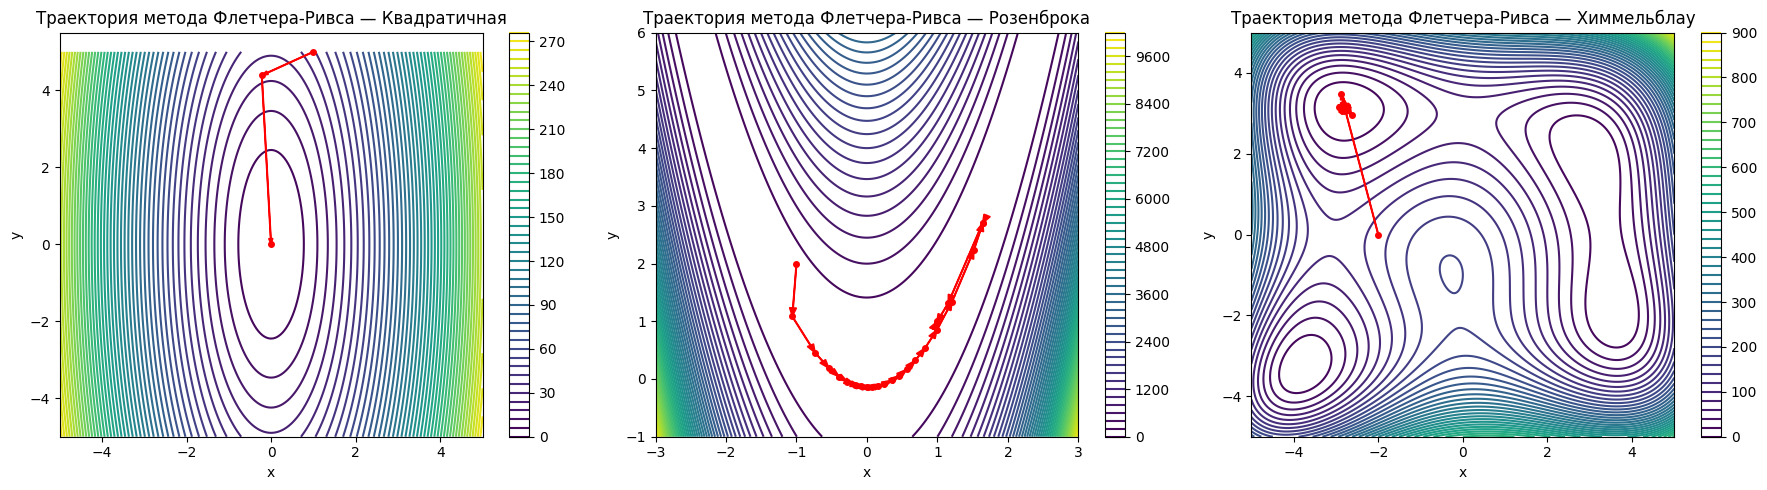

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_topography(func, points, x_range, y_range, title, ax):

    x = np.linspace(x_range[0], x_range[1], 400)
    y = np.linspace(y_range[0], y_range[1], 400)

    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    contour = ax.contour(X, Y, Z, levels=50)
    plt.colorbar(contour, ax=ax)

    # равномерное прореживание вместо обрезки
    if len(points) > 40:
        idx = np.linspace(0, len(points) - 1, 25, dtype=int)
        p = points[idx]
    else:
        p = points

    px = p[:, 0]
    py = p[:, 1]

    ax.plot(px, py, 'ro-', markersize=4)

    # стрелки (как у тебя было)
    for i in range(len(p) - 1):
        dx = px[i+1] - px[i]
        dy = py[i+1] - py[i]

        ax.arrow(px[i], py[i], dx, dy,
                 head_width=0.1,
                 length_includes_head=True,
                 color='red')

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

ranges = [
    ((-5, 5), (-5, 5)),
    ((-3, 3), (-1, 6)),
    ((-5, 5), (-5, 5))
]

# создаём одну строку графиков
fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 5))

# если график один — приводим к списку
if len(functions) == 1:
    axes = [axes]

for i, (name, func, _, _) in enumerate(functions):

    points = fletcher_descent_points[i][0]

    plot_topography(
        func,
        points,
        ranges[i][0],
        ranges[i][1],
        "Траектория метода Флетчера-Ривса — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

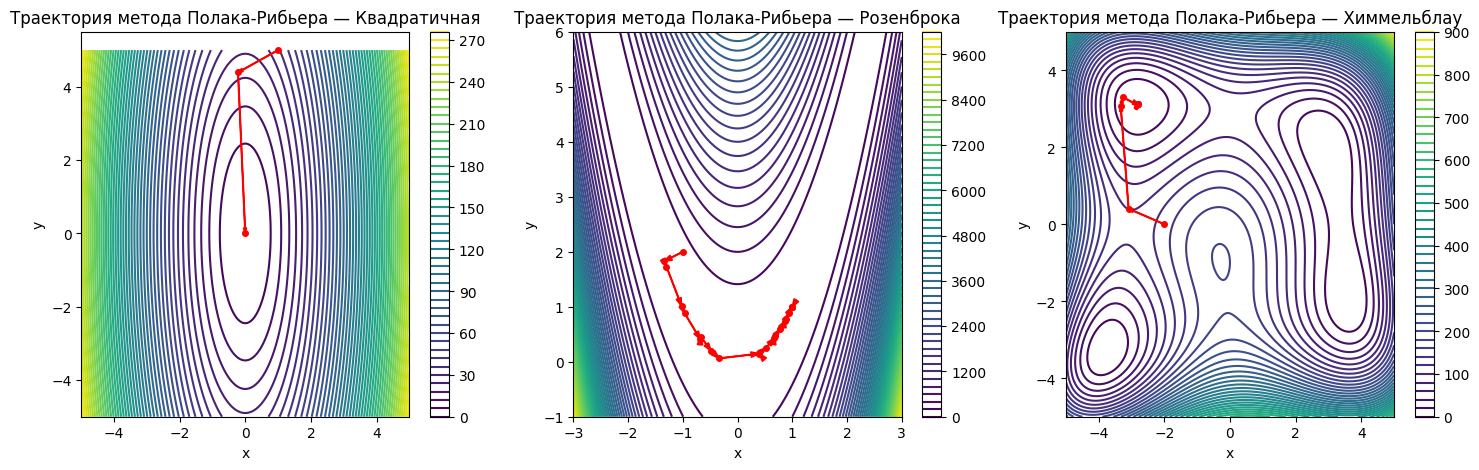

In [ ]:
method_name = "Траектория метода Полака-Рибьера"

fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 5))

if len(functions) == 1:
    axes = [axes]

for i, (name, func, _, _) in enumerate(functions):

    points = polak_descent_points[i][0]

    plot_topography(
        func,
        points,
        ranges[i][0],
        ranges[i][1],
        f"{method_name} — {name}",
        axes[i]
    )

plt.tight_layout()
plt.show()

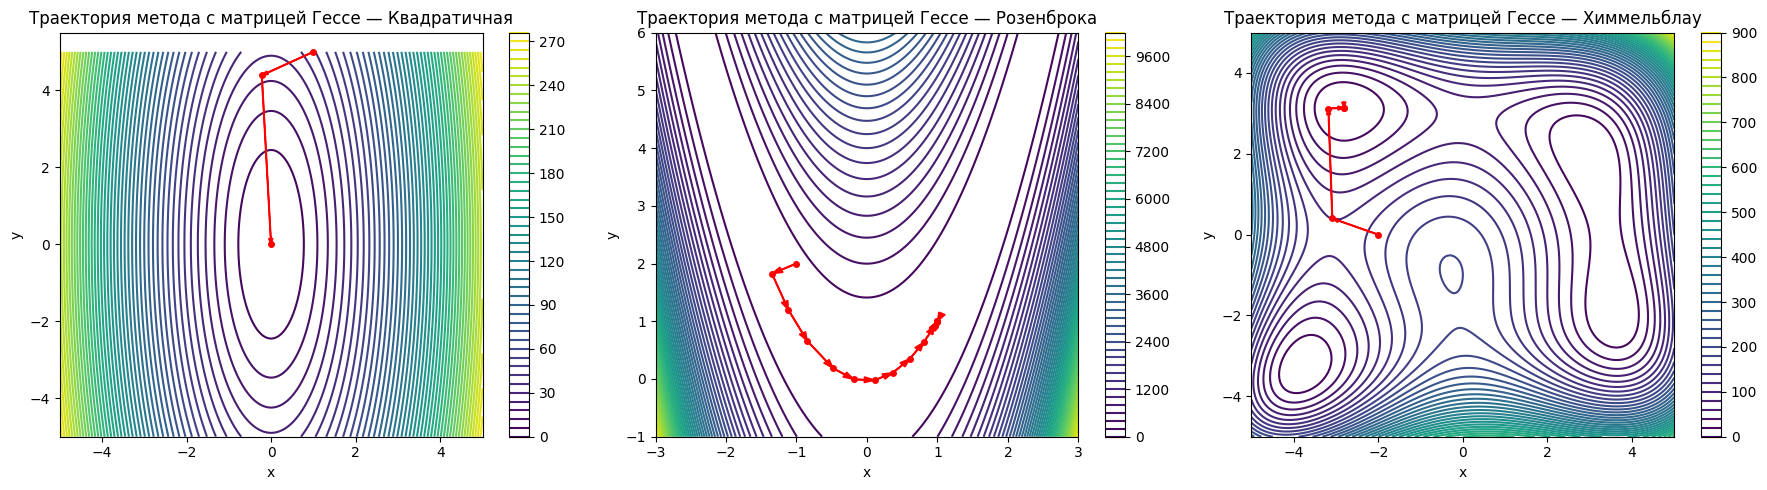

In [ ]:
method_name = "Траектория метода с матрицей Гессе"

fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 5))

if len(functions) == 1:
    axes = [axes]

for i, (name, func, _, _) in enumerate(functions):

    points = hesse_descent_points[i][0]

    plot_topography(
        func,
        points,
        ranges[i][0],
        ranges[i][1],
        f"{method_name} — {name}",
        axes[i]
    )

plt.tight_layout()
plt.show()

#### Нормы градиента

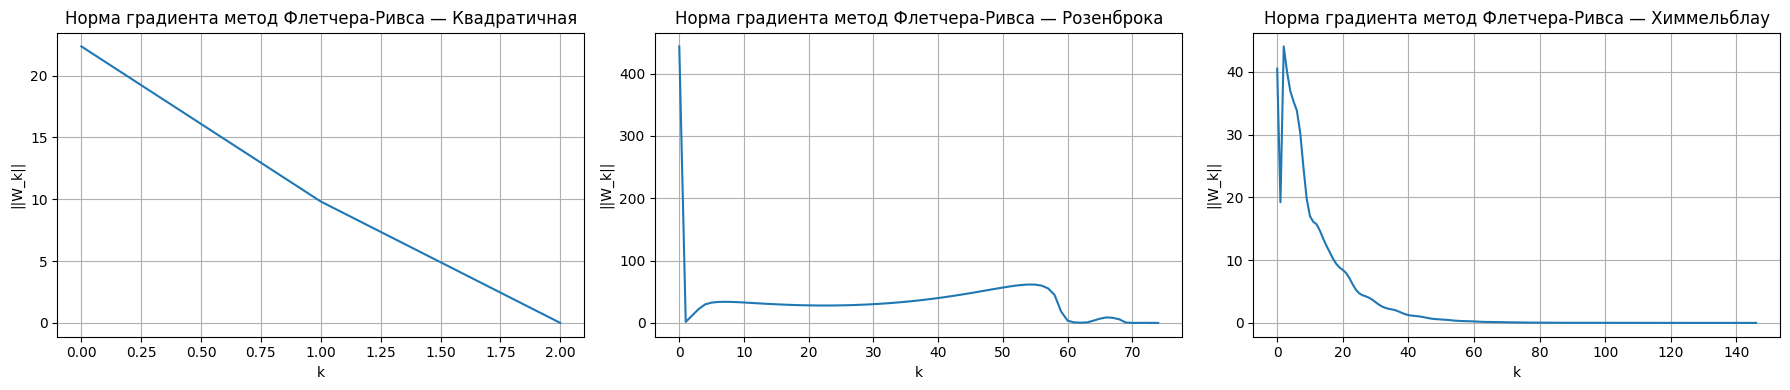

In [ ]:
def plot_grad_norm(grad_norms, title, ax):

    k = np.arange(len(grad_norms))

    ax.plot(k, grad_norms)

    ax.set_xlabel("k")
    ax.set_ylabel("||W_k||")
    ax.set_title(title)

    ax.grid()


fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = fletcher_descent_points[i][1]

    plot_grad_norm(
        grad_norms,
        "Норма градиента метод Флетчера-Ривса — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

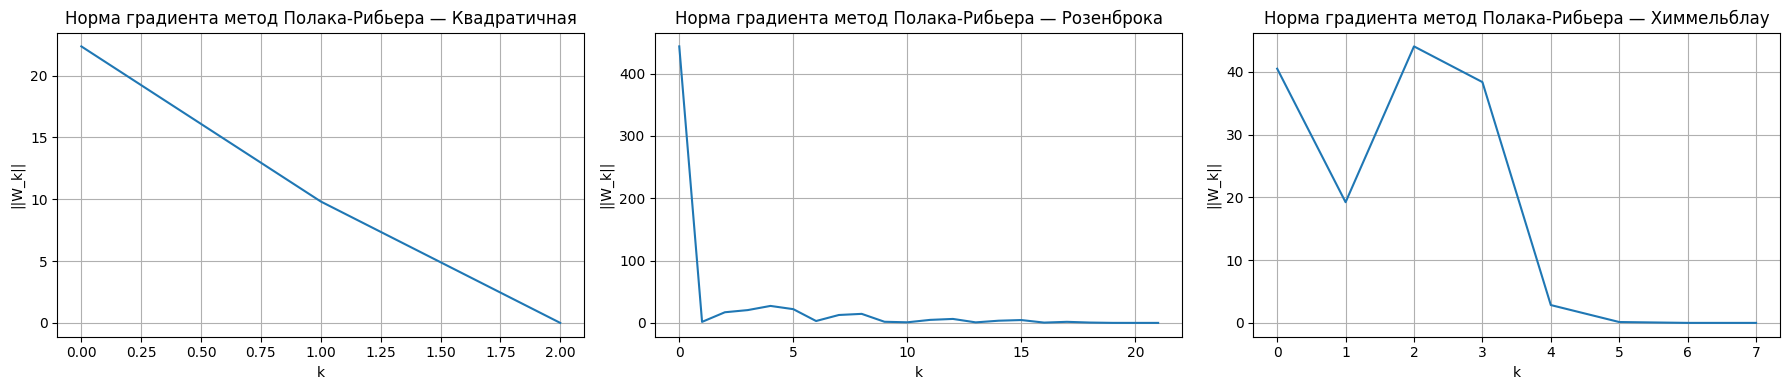

In [ ]:
fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = polak_descent_points[i][1]

    plot_grad_norm(
        grad_norms,
        "Норма градиента метод Полака-Рибьера — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

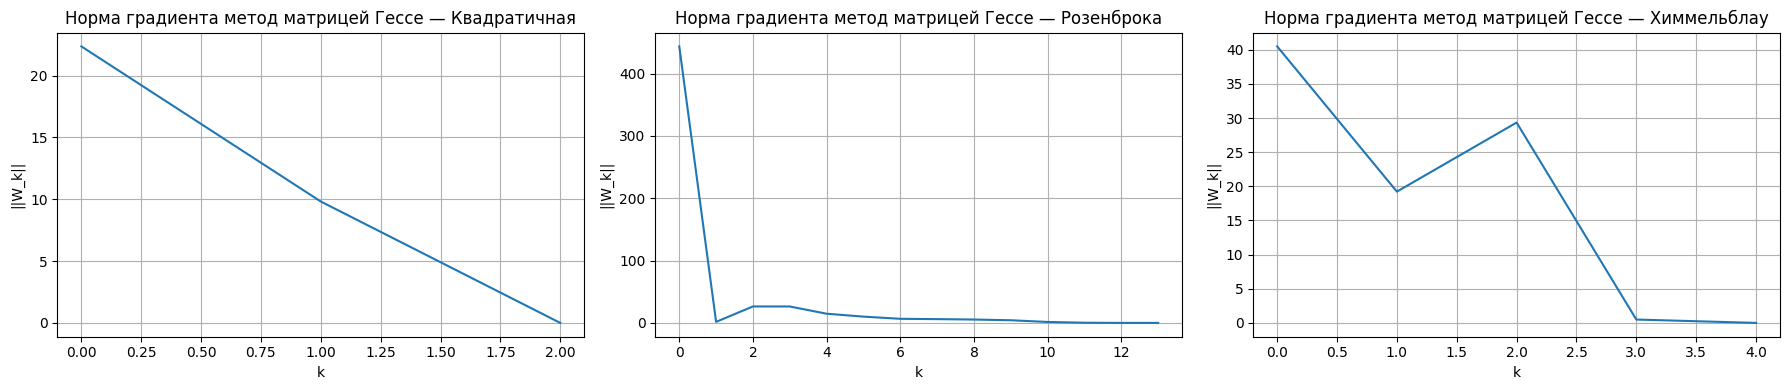

In [ ]:
fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = hesse_descent_points[i][1]

    plot_grad_norm(
        grad_norms,
        "Норма градиента метод матрицей Гессе — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

#### Логарифмические нормы градиента

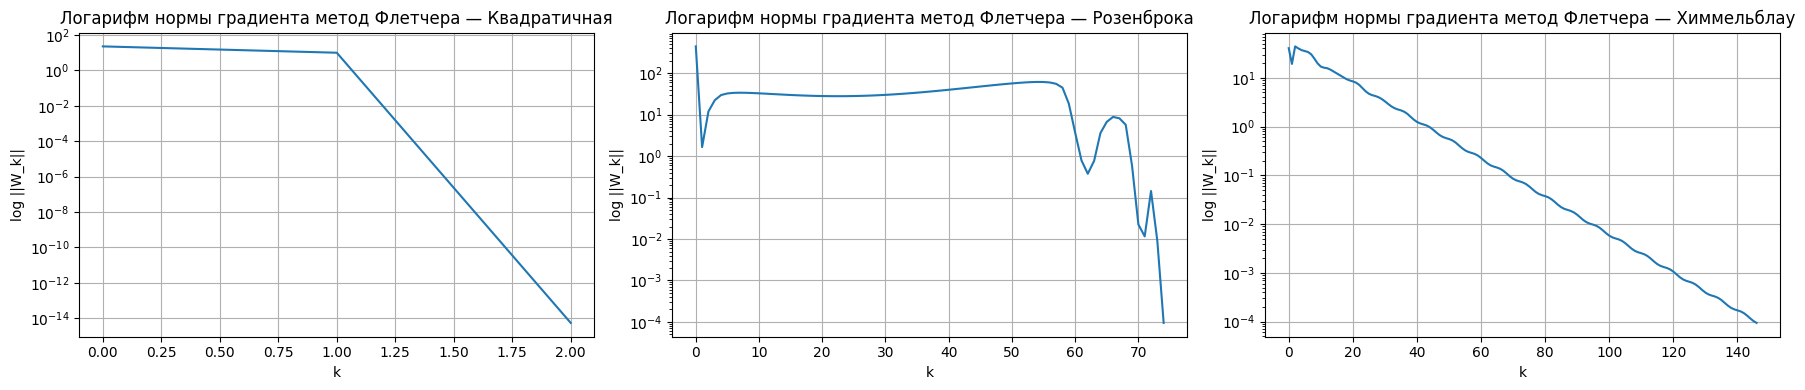

In [ ]:
def plot_grad_norm_log(grad_norms, title, ax):

    k = np.arange(len(grad_norms))

    ax.semilogy(k, grad_norms)

    ax.set_xlabel("k")
    ax.set_ylabel("log ||W_k||")
    ax.set_title(title)

    ax.grid()


fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = fletcher_descent_points[i][1]

    plot_grad_norm_log(
        grad_norms,
        "Логарифм нормы градиента метод Флетчера — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

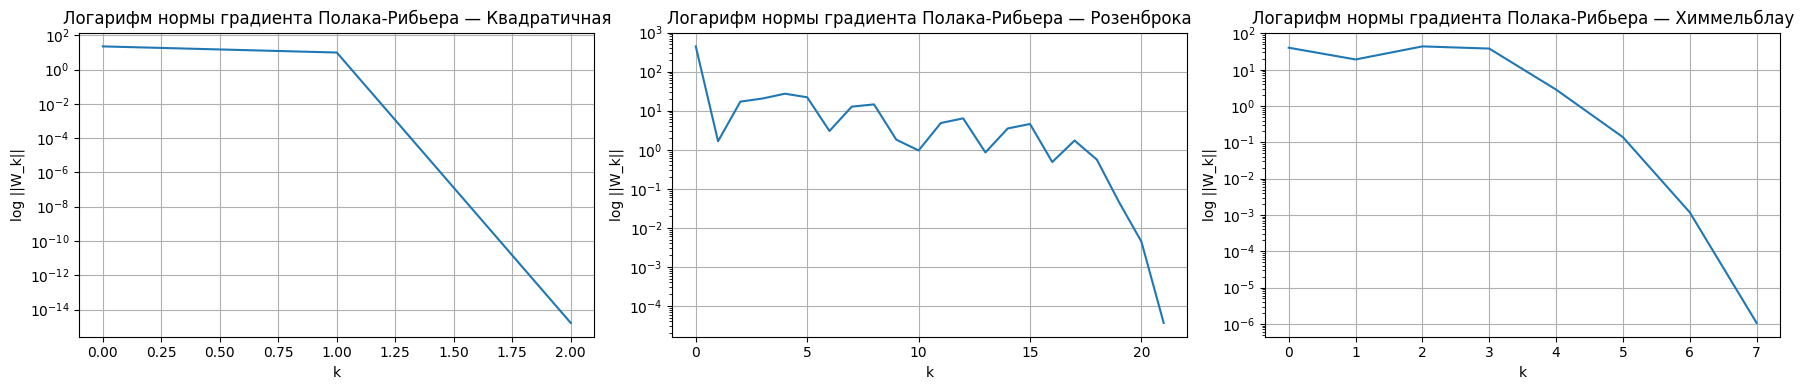

In [ ]:
fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = polak_descent_points[i][1]

    plot_grad_norm_log(
        grad_norms,
        "Логарифм нормы градиента Полака-Рибьера — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()

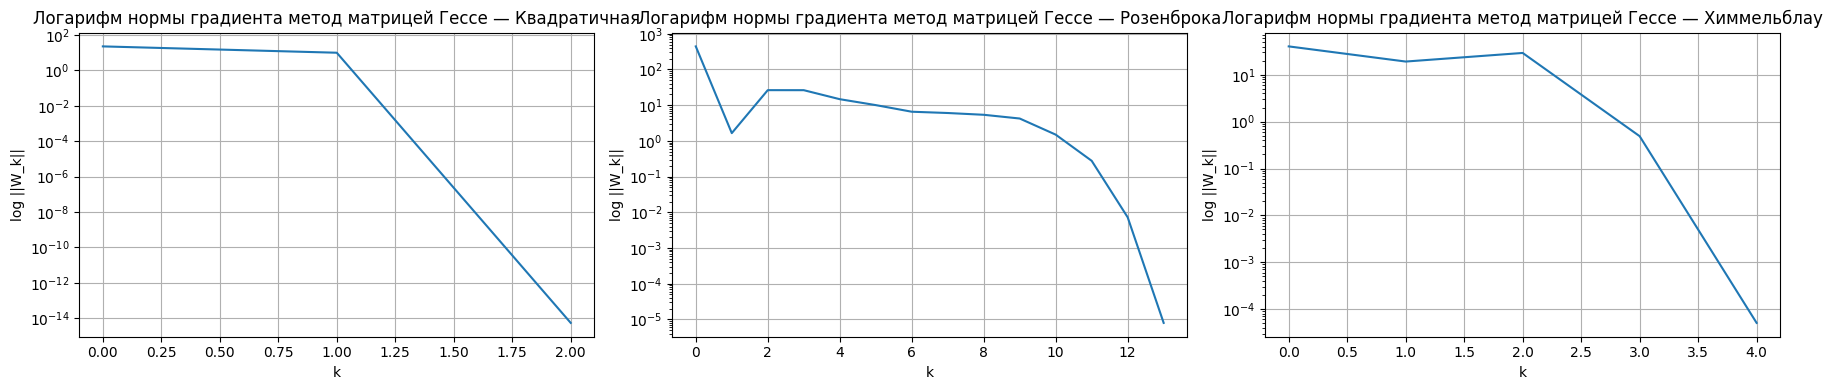

In [ ]:
fig, axes = plt.subplots(1, len(functions), figsize=(6 * len(functions), 4))

# если одна функция
if len(functions) == 1:
    axes = [axes]

for i, (name, _, _, _) in enumerate(functions):

    grad_norms = hesse_descent_points[i][1]

    plot_grad_norm_log(
        grad_norms,
        "Логарифм нормы градиента метод матрицей Гессе — " + name,
        axes[i]
    )

plt.tight_layout()
plt.show()